In [8]:
import pandas as pd
import geopandas as gpd
import rioxarray
from shapely.geometry import  Point
import cv2
import matplotlib.pyplot as plt
from georefcam.camera_model import CTCameraModel
from georefcam.dem import RasterioDEM
from georefcam.georefcam import GeoRefCam, get_direction_vector
import numpy as np
import pyvista as pv
import rioxarray
from PIL import Image
import glob
import os
from tqdm import tqdm
from shapely.ops import unary_union
import json
import numpy as np
from pyproj import CRS, Transformer
from georefcam.camera_model import CTCameraModel  # your actual class
import pandas as pd
from shapely.geometry import Point
from dem_utils import compute_dem_bbox_from_point, download_dem_eio, reproject_and_save_dem

In [9]:
def check_camera_in_dem(cam_loc, dem_points):
    # Get DEM bounds
    x_min, x_max = dem_points[:, :, 0].min(), dem_points[:, :, 0].max()
    y_min, y_max = dem_points[:, :, 1].min(), dem_points[:, :, 1].max()
    z_min, z_max = dem_points[:, :, 2].min(), dem_points[:, :, 2].max()

    cam_x, cam_y, cam_z = cam_loc

    in_x = x_min <= cam_x <= x_max
    in_y = y_min <= cam_y <= y_max
    inside_dem = in_x and in_y

    # Distance to borders (always positive)
    dx_left = abs(cam_x - x_min)
    dx_right = abs(x_max - cam_x)
    dy_bottom = abs(cam_y - y_min)
    dy_top = abs(y_max - cam_y)

    print(f"📷 Camera location (XYZ): {cam_loc}")
    print(f"🗺️  DEM bounds: X ({x_min:.1f} to {x_max:.1f})")
    print(f"               Y ({y_min:.1f} to {y_max:.1f})")
    print(f"               Z ({z_min:.1f} to {z_max:.1f})")
    print(f"📌 Inside DEM (XY): {inside_dem}")
    print(f"↔️  Distance to X borders: left={dx_left:.1f} m, right={dx_right:.1f} m")
    print(f"↕️  Distance to Y borders: bottom={dy_bottom:.1f} m, top={dy_top:.1f} m")

    if not inside_dem:
        print("⚠️  WARNING: Camera is outside DEM bounds")

    return {
        "inside": inside_dem,
        "dx_left": dx_left,
        "dx_right": dx_right,
        "dy_bottom": dy_bottom,
        "dy_top": dy_top
    }


In [10]:
name = "nemours"


# === Load Camera Metadata ===
with open(f"site_data/{name}/camera_config.json", "r") as f:
    loaded_config = json.load(f)

# Extract values
lat = loaded_config["lat"]
lon = loaded_config["lon"]

tilt = loaded_config["tilt"]
roll = loaded_config["roll"]
elevation = loaded_config["elevation"]
fov_x = loaded_config["fov_x"]
fov_y = loaded_config["fov_y"]
img_size = tuple(loaded_config["img_size"])

# Use name as login or define separately
cam_name = name

# === Camera Info as GeoDataFrame ===
cam_info = pd.Series({
    "login": cam_name,
    "lat": lat,
    "lon": lon,
    "geometry": Point(lon, lat),
    "azimuth": 0.0,
    "tilt": tilt,
    "elevation": elevation,
    "roll": roll,
})
gdf_cams = gpd.GeoDataFrame([cam_info], geometry="geometry", crs="EPSG:4326")

In [11]:
# bbox = compute_dem_bbox_from_point(lat, lon, buffer_km=30)
# download_dem_eio(bbox)
# reproject_and_save_dem("srtm_dem.tif", "srtm_dem_l93.tif")

In [12]:
# === Prepare DEM ===
dem_data = rioxarray.open_rasterio(f"data/lidar_data/{name}/dsm_min.tif", masked=True).squeeze()
if dem_data.rio.crs != "EPSG:2154":
    dem_data = dem_data.rio.reproject("EPSG:2154")
dem_path = "dem_l93.tif"
dem_data.rio.to_raster(dem_path)

dem = RasterioDEM(dem_path, crs="EPSG:2154")
dem.build_pcd(sample_step=2)
dem.build_mesh()

print("[DEBUG] Mesh bounds:", dem.mesh.bounds)
print("[DEBUG] Mesh extents (X/Y):", dem.mesh.extents[:2])
print("[DEBUG] Mesh centroid:", dem.mesh.centroid)

mesh.vertices.shape = (12257001, 3)
mesh.vertices[:5] = [[6.7499977e+05 6.7990000e+06 8.2380000e+01]
 [6.7500177e+05 6.7990000e+06 8.2370000e+01]
 [6.7500377e+05 6.7990000e+06 8.2410000e+01]
 [6.7500577e+05 6.7990000e+06 8.2430000e+01]
 [6.7500777e+05 6.7990000e+06 8.2260000e+01]]
[DEBUG] Mesh bounds: [[ 6.7499977e+05  6.7920000e+06 -9.9990000e+03]
 [ 6.8199977e+05  6.7990000e+06  1.4826000e+02]]
[DEBUG] Mesh extents (X/Y): [7000. 7000.]
[DEBUG] Mesh centroid: [ 6.77572880e+05  6.79561934e+06 -4.53278495e+03]


In [13]:



azimuth = 42


cam_crs = CRS.from_user_input("EPSG:2154")


# === Step 1: Instantiate your camera model ===
cam_model = CTCameraModel(
    image_res   = img_size,
    fov_x_deg   = fov_x,
    fov_y_deg   = fov_y,
    azimuth_deg = azimuth,
    tilt_deg    = tilt,
    roll_deg    = cam_info.roll,
    lat         = cam_info.lat,
    lon         = cam_info.lon,
    elevation   = cam_info.elevation,
    crs         = cam_crs.to_string()
)

# === Step 2: Compute center pixel ray ===
w, h = cam_model.image_res
center_pixel = np.array([[w / 2, h / 2]], dtype=float)
rays = cam_model.project_pixel_points_to_world_rays(center_pixel)

origin = rays[0, :, 0]
target = rays[0, :, 1]

# === Step 3: Reproject to WGS84 ===
lon_o, lat_o = cam_model.tf_local_to_wgs84.transform(origin[0], origin[1])
lon_t, lat_t = cam_model.tf_local_to_wgs84.transform(target[0], target[1])


# === Step 4: Compute WGS84 azimuth ===
def compute_azimuth(lat1, lon1, lat2, lon2):
    dlon = np.radians(lon2 - lon1)
    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    y = np.sin(dlon) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    return (np.degrees(np.arctan2(y, x)) + 360) % 360

computed_az = compute_azimuth(lat_o, lon_o, lat_t, lon_t)

# === Final output ===
print(f"Expected azimuth: {azimuth:.2f}°")
print(f"Computed center ray azimuth (WGS84): {computed_az:.2f}°")


Expected azimuth: 42.00°
Computed center ray azimuth (WGS84): 42.00°


In [14]:
fov_x/4

13.5

In [15]:
# === Step 1: Compute camera location and direction ===
geocam = GeoRefCam(cam_model, dem)

cam_dirvec = get_direction_vector(geocam.camera_model.azimuth_deg, geocam.camera_model.tilt_deg)

# Reproject camera location if needed
if geocam.camera_model.cam_loc[3] != geocam.dem.crs:
    cam_loc = geocam.project_points_from_cam_to_dem_crs(
        np.array([geocam.camera_model.cam_loc[:3]])
    )[0]
else:
    cam_loc = geocam.camera_model.cam_loc[:3]


📷 Camera XYZ: (678216.3567650379, 6795614.403574749, 153)
➡️ Direction Vector: [ 0.66750064  0.74133456 -0.06975647]
📐 Vertical FOV: 31.985459249621822
🔧 Mesh points: 12146719
🔧 Bounds: BoundsTuple(x_min=674999.77, x_max=681999.77, y_min=6792000.0, y_max=6799000.0, z_min=53.65, z_max=148.26)


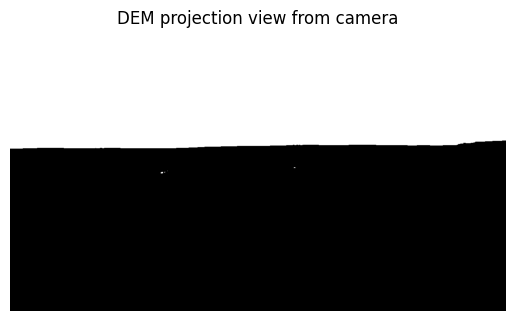

In [16]:


# === Step 1: Build GeoRefCam ===
geocam = GeoRefCam(cam_model, dem)

# === Step 2: Camera position and direction ===
cam_dirvec = get_direction_vector(geocam.camera_model.azimuth_deg, geocam.camera_model.tilt_deg)

if geocam.camera_model.cam_loc[3] != geocam.dem.crs:
    cam_loc = geocam.project_points_from_cam_to_dem_crs(np.array([geocam.camera_model.cam_loc[:3]]))[0]
else:
    cam_loc = geocam.camera_model.cam_loc[:3]

print("📷 Camera XYZ:", cam_loc)
print("➡️ Direction Vector:", cam_dirvec)

# === Step 3: Compute vertical FOV ===
w, h = geocam.camera_model.image_res
fov_y_deg = 2 * np.degrees(
    np.arctan(np.tan(np.radians(geocam.camera_model.fov_x_deg / 2)) * (h / w))
)
print("📐 Vertical FOV:", fov_y_deg)

# === Step 4: Setup PyVista camera ===
pv_camera = pv.Camera()
pv_camera.position = cam_loc
pv_camera.focal_point = cam_loc + cam_dirvec
pv_camera.view_angle = fov_y_deg
pv_camera.clipping_range = (1, 10000)
pv_camera.up = (0, 0, 1)

# === Step 5: PyVista structured grid ===
z = geocam.dem.pcd[:, :, 2]
z[z < -1000] = np.nan
geocam.dem.pcd[:, :, 2] = z

grid = pv.StructuredGrid(*[geocam.dem.pcd[:, :, i] for i in range(3)])
grid["alt"] = z.ravel(order="F")

# === Step 6: Remove invalid (water) points
valid_grid = grid.threshold(value=-999, scalars="alt", invert=False)

print("🔧 Mesh points:", valid_grid.n_points)
print("🔧 Bounds:", valid_grid.bounds)

# === Step 7: Render
plotter = pv.Plotter(off_screen=True, window_size=(w, h))
plotter.camera = pv_camera
plotter.add_mesh(valid_grid, scalars="alt", lighting=False)
plotter.remove_scalar_bar()

# ✅ Must render manually before accessing depth
plotter.screenshot()

# Step 9: Capture depth map
dem_depth = -1 * plotter.get_image_depth()
dem_depth = np.nan_to_num(dem_depth, nan=1e6)

# === Step 8: Show image
plt.imshow(dem_depth, cmap='gray')
plt.title("DEM projection view from camera")
plt.axis('off')
plt.show()


In [17]:
np.save("dem_depth.npy", dem_depth)

In [18]:
dem_depth2  = np.load("dem_depth.npy" )

In [19]:
arr = dem_depth2.copy()
mask = arr==arr.max()

arr[mask] = 0
min_val = np.nanpercentile(arr[~mask], 0)
max_val = np.nanpercentile(arr[~mask], 95)
print(azimuth, min_val, max_val)
norm = (arr - min_val) / (max_val - min_val)
norm = np.clip(norm, 0, 1)

result = np.zeros_like(arr, dtype="float32")
result[~mask] = norm[~mask] * 255

42 184.8501739501953 1906.6342468261716


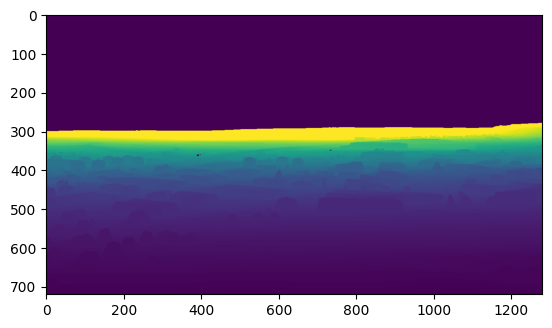

In [20]:
plt.imshow(result)

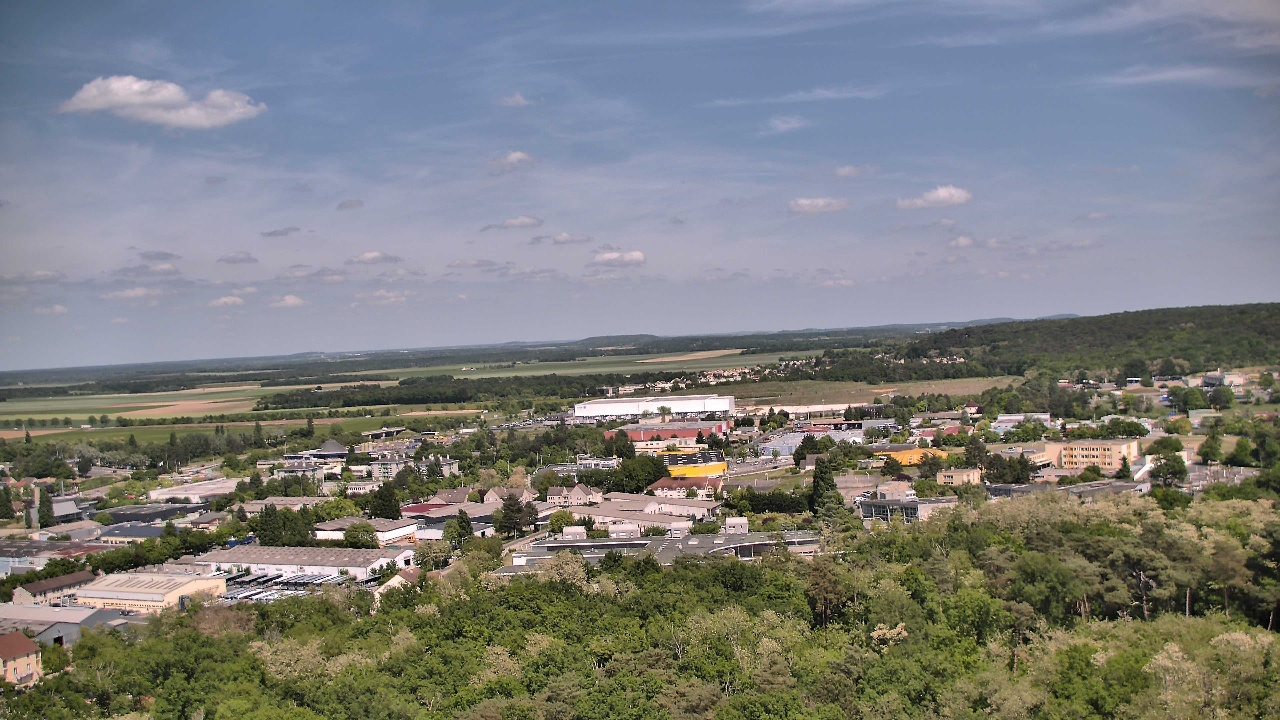

In [23]:
cam_img_path = "site_data/nemours/captured_poses/192_168_1_11/192_168_1_11_im_2.jpg"
Image.open(cam_img_path)